In [1]:
import stim

xx = stim.PauliString("+XX")
zz = stim.PauliString("+ZZ")

# Pauli strings can be multiplied
mul_res = xx * zz
print("Multiplication: XX * ZZ = ", mul_res)

# Pauli strings can be concatenated
add_res = xx + zz
print("Addition: XX + ZZ = ", add_res)

# We can check if 2 Pauli strings commute
print("XX and ZZ commute: ", xx.commutes(zz))

Multiplication: XX * ZZ =  -YY
Addition: XX + ZZ =  +XXZZ
XX and ZZ commute:  True


In [2]:
# Define a Tableau simulator
simulator = stim.TableauSimulator()

In [13]:
from stim import PauliString

x_stabilizers = [
    PauliString("XXXXIII"),
    PauliString("IXXIXXI"),
    PauliString("IIXXIXX"),
]

z_stabilizers = [
    PauliString("ZZZZIII"),
    PauliString("IZZIZZI"),
    PauliString("IIZZIZZ"),
]

steane_stabilizer = x_stabilizers + z_stabilizers

from itertools import combinations

s_comm = [m.commutes(n) for m, n in combinations(steane_stabilizer, 2)]
print(s_comm)

log_x = PauliString("XXXXXXX") 
log_z = PauliString("ZZZZZZZ") 

# Conjugate the stabilizers one by one with the logical observables and compare the lists
conj_log_x = [log_x*s*log_x for s in steane_stabilizer]
conj_log_z = [log_z*s*log_z for s in steane_stabilizer]

display(conj_log_x)
display(conj_log_z)

# Logical operators anti-commute
display(log_z.commutes(log_x))

[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


[stim.PauliString("+XXXX___"),
 stim.PauliString("+_XX_XX_"),
 stim.PauliString("+__XX_XX"),
 stim.PauliString("+ZZZZ___"),
 stim.PauliString("+_ZZ_ZZ_"),
 stim.PauliString("+__ZZ_ZZ")]

[stim.PauliString("+XXXX___"),
 stim.PauliString("+_XX_XX_"),
 stim.PauliString("+__XX_XX"),
 stim.PauliString("+ZZZZ___"),
 stim.PauliString("+_ZZ_ZZ_"),
 stim.PauliString("+__ZZ_ZZ")]

False

In [14]:
def equivalent_logicals(logical, stabilizers):
    equivalents = []
    for mask in range(1 << len(stabilizers)):
        stabilizer_product = PauliString("_______")
        for k, generator in enumerate(stabilizers):
            if mask & (1 << k):
                stabilizer_product *= generator
        equivalents.append(str(logical * stabilizer_product))
    return sorted(set(equivalents), key=lambda p: (sum(c in "XYZ" for c in p), p))

equiv_log_x = equivalent_logicals(log_x, x_stabilizers)
equiv_log_z = equivalent_logicals(log_z, z_stabilizers)

print("Equivalent X logical observables:")
for op in equiv_log_x:
    print(op)

print("\nEquivalent Z logical observables:")
for op in equiv_log_z:
    print(op)


Equivalent X logical observables:
+XX__X__
+X_X__X_
+X__X__X
+_XX___X
+_X_X_X_
+__XXX__
+____XXX
+XXXXXXX

Equivalent Z logical observables:
+ZZ__Z__
+Z_Z__Z_
+Z__Z__Z
+_ZZ___Z
+_Z_Z_Z_
+__ZZZ__
+____ZZZ
+ZZZZZZZ


In [16]:
def encoding_circuit(log_qb_idx: int = 0) -> stim.Circuit:
    """Encoding scheme proposed by Goto 2015:
        https://www.nature.com/articles/srep19578

    To prepare the logical Steane qubit in state |0>_L.
    The qubit index allows shifting the indices so that
    we can prepare multiple logical qubits.
    """
    c = stim.Circuit()
    # shift registers to target logical qubit with given index
    s = log_qb_idx * 8

    c.append("H", [s, 4 + s, 6 + s])
    c.append("CNOT", [s, 1 + s])
    c.append("CNOT", [4 + s, 5 + s])
    c.append("CNOT", [6 + s, 3 + s])
    c.append("CNOT", [6 + s, 5 + s])
    c.append("CNOT", [4 + s, 2 + s])
    c.append("CNOT", [0 + s, 3 + s])
    c.append("CNOT", [4 + s, 1 + s])
    c.append("CNOT", [3 + s, 2 + s])

    # Entangle with ancilla qubit and measure logical Pauli-Z
    c.append("CNOT", [1 + s, 7 + s])
    c.append("CNOT", [3 + s, 7 + s])
    c.append("CNOT", [5 + s, 7 + s])
    c.append("M", [7 + s])

    return c

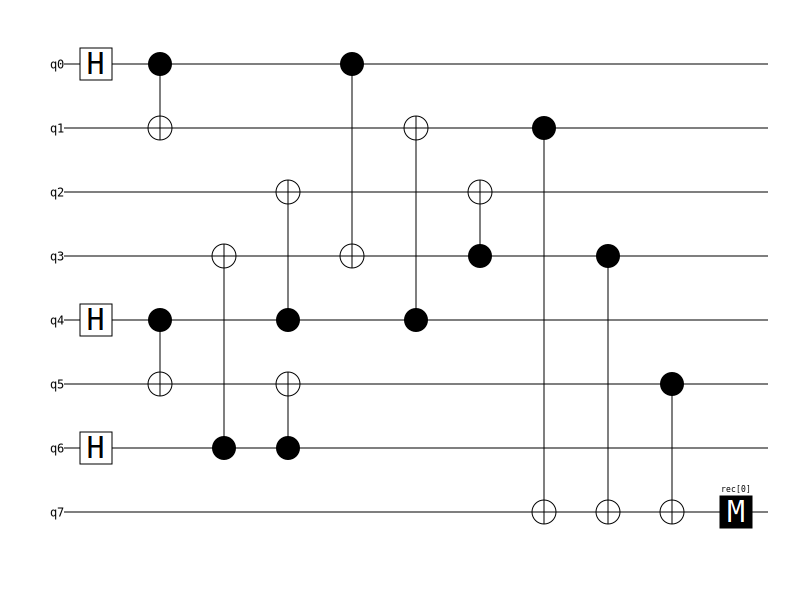

In [17]:
c = stim.Circuit()
c += encoding_circuit()
c.diagram("timeline-svg")

In [18]:
t = c.to_tableau(ignore_measurement=True)
print("Stabilizers")
t.to_stabilizers()

Stabilizers


[stim.PauliString("+XXXX____"),
 stim.PauliString("+ZZ__Z___"),
 stim.PauliString("+__ZZZ___"),
 stim.PauliString("+Z__Z__Z_"),
 stim.PauliString("+_XX_XX__"),
 stim.PauliString("+____ZZZ_"),
 stim.PauliString("+__XX_XX_"),
 stim.PauliString("+_Z_Z_Z_Z")]

In [19]:
import numpy as np


def measure_logical_qubits(log_qubit_indices: list[int] = [0]) -> stim.Circuit:
    c = stim.Circuit()

    for log_qubit_index in log_qubit_indices:
        # shift index
        s = log_qubit_index * 8
        # final measurement
        c.append("M", np.array([0, 1, 2, 3, 4, 5, 6]) + s)

    return c


def sample_from_circuit(c: stim.Circuit, shots: int = 10) -> np.array:
    # compile a sampler and sample 10 shots
    s = c.compile_sampler()
    r = s.sample(shots=shots).astype(int)

    return r